# **Predicting Social Anxiety Levels Using Behavioral, Lifestyle, and Psychological Factors: A Comparison of Ordinal Logistic Regression and Random Forest**

The project aims to determine behavioral, lifestyle, and psychological factors among other that may serve as predictors for mild to severe social anxiety. We then compared an ordinal logistic regression model and random forest model to determine which model worked best. The response variable is an ordinal anxiety score ranging from 1 (lowest anxiety) to 10 (highest anxiety), making the problem an ordinal classification task.

Overall, the random forest model did best across all metrics (accuracy, precision, f1, recall, mean absolute error, and quadratic weighted Kohen's kappa). These findings suggest that the relationship between behavioral, lifestyle, psychological, and physiological factors and social anxiety severity is likely nonlinear, making Random Forest a more suitable predictive model for this dataset.

This is a continuation of a discontinued high school research project. I dedicate this project to my Grade 11 Calculus teacher.

**Setups and Imports**

In [56]:
from google.colab import files

uploaded = files.upload()

Saving enhanced_anxiety_dataset.csv to enhanced_anxiety_dataset (2).csv


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("enhanced_anxiety_dataset.csv")

**Some EDA**

In [58]:
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


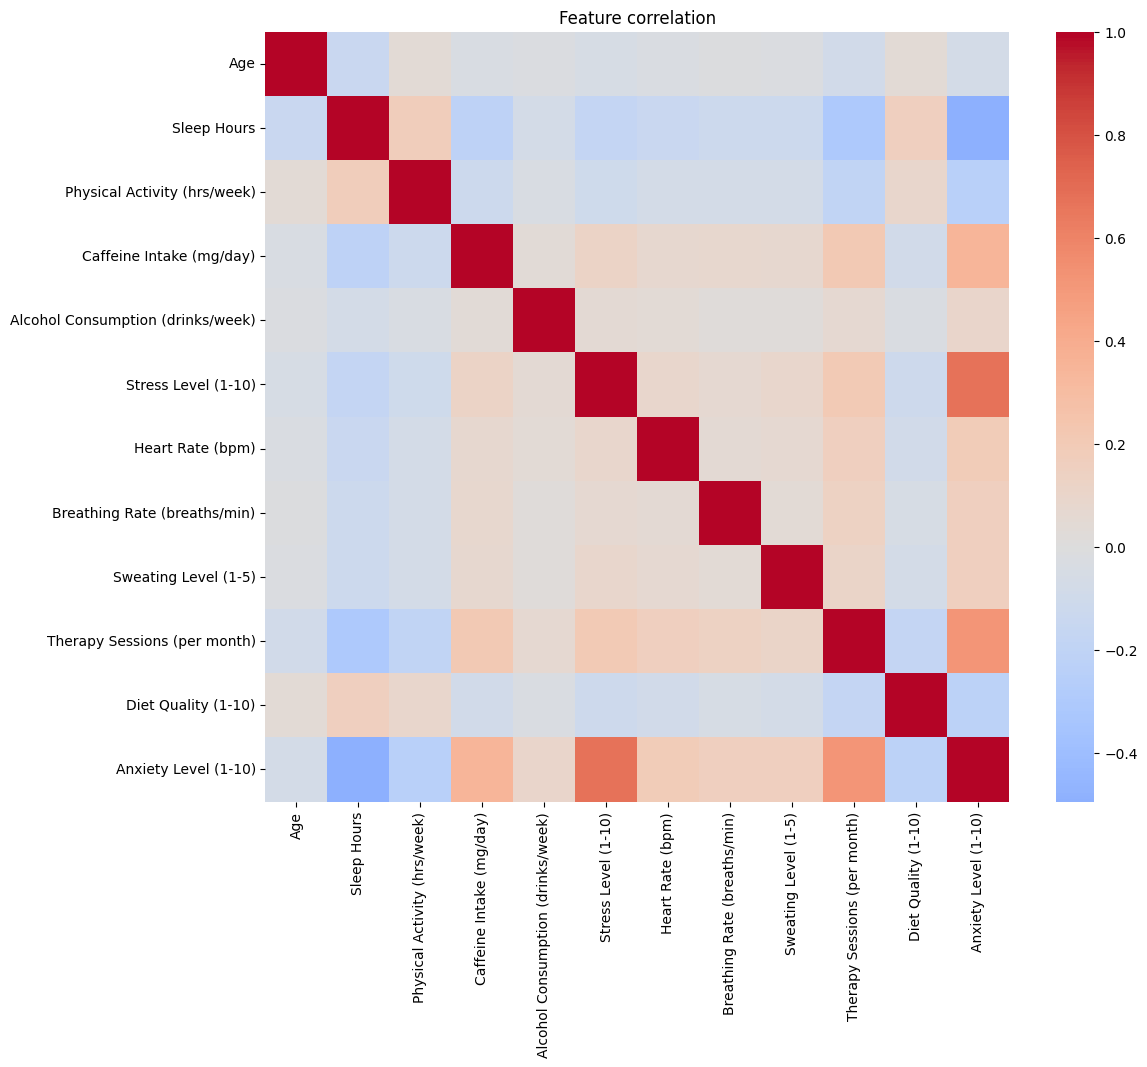

In [59]:
plt.figure(figsize=(12, 10))

corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title('Feature correlation')
plt.show()

**Hot Encoding Categorical Variables**

In [60]:
# gender and occupation
df = pd.get_dummies(
    df,
    columns=["Gender", "Occupation"],
    drop_first=True,
    dtype=int
)

# everything else (has bool True or False vals)
binary_cols = [
    "Smoking",
    "Family History of Anxiety",
    "Dizziness",
    "Medication",
    "Recent Major Life Event"
]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [61]:
# to make sure that everything are integers
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [62]:
df.head()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
0,29,6.0,2.7,181,10,1,0,10,114,14,...,0,0,0,0,0,0,0,0,0,0
1,46,6.2,5.7,200,8,1,1,1,62,23,...,0,0,0,0,0,1,0,0,0,0
2,64,5.0,3.7,117,4,0,1,1,91,28,...,0,0,0,0,0,0,1,0,0,0
3,20,5.8,2.8,360,6,1,0,4,86,17,...,0,0,0,0,0,0,0,1,0,0
4,49,8.2,2.3,247,4,1,0,1,98,19,...,0,0,0,0,0,0,1,0,0,0


In [63]:
df.columns

Index(['Age', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)', 'Dizziness', 'Medication',
       'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)', 'Gender_Male',
       'Gender_Other', 'Occupation_Athlete', 'Occupation_Chef',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Freelancer',
       'Occupation_Lawyer', 'Occupation_Musician', 'Occupation_Nurse',
       'Occupation_Other', 'Occupation_Scientist', 'Occupation_Student',
       'Occupation_Teacher'],
      dtype='object')

**Splitting Data**

In [64]:
X = df.drop(columns=["Anxiety Level (1-10)"])
y = df["Anxiety Level (1-10)"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y)
print('Regression train/test sizes:', Xr_train.shape, Xr_test.shape)

Regression train/test sizes: (8800, 30) (2200, 30)


## **Ordinal Logistic Regression**

**Model Training**

In [65]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(Xr_train)
X_test = scaler.transform(Xr_test)

model = OrderedModel(yr_train, Xr_train, distr="logit")
result = model.fit(method="bfgs")

y_pred = result.predict(Xr_test).idxmax(axis=1)

Optimization terminated successfully.
         Current function value: 1.455626
         Iterations: 102
         Function evaluations: 109
         Gradient evaluations: 109


**Model Evaluation**

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score,
    mean_absolute_error,
)

# Overall metrics
print("Ordinal Logistic Regression Metrics")
print("-----------------------------------")
print(f"Accuracy: {accuracy_score(yr_test, y_pred):.4f}")
print(f"Precision (Weighted): {precision_score(yr_test, y_pred, average='weighted'):.4f}")
print(f"Recall (Weighted): {recall_score(yr_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score (Weighted): {f1_score(yr_test, y_pred, average='weighted'):.4f}")

# Ordinal-specific metrics
print(f"Mean Absolute Error: {mean_absolute_error(yr_test, y_pred):.4f}")
print(f"Quadratic Weighted Kappa: {cohen_kappa_score(yr_test, y_pred, weights='quadratic'):.4f}")

print("\nClassification Report")
print(classification_report(yr_test, y_pred_rf, zero_division=0))

Ordinal Logistic Regression Metrics
-----------------------------------
Accuracy: 0.2305
Precision (Weighted): 0.2490
Recall (Weighted): 0.2305
F1 Score (Weighted): 0.2139
Mean Absolute Error: 1.2250
Quadratic Weighted Kappa: 0.7454

Classification Report
              precision    recall  f1-score   support

         1.0       0.49      0.30      0.38       208
         2.0       0.33      0.35      0.34       351
         3.0       0.35      0.39      0.37       481
         4.0       0.33      0.43      0.37       483
         5.0       0.37      0.36      0.37       326
         6.0       0.11      0.01      0.02       123
         7.0       0.00      0.00      0.00        25
         8.0       0.26      0.29      0.27        73
         9.0       0.35      0.33      0.34        66
        10.0       0.23      0.22      0.23        64

    accuracy                           0.34      2200
   macro avg       0.28      0.27      0.27      2200
weighted avg       0.34      0.34      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


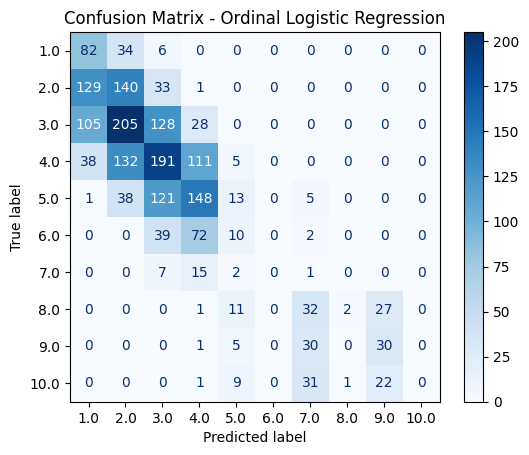

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(yr_test.unique())

cm = confusion_matrix(
    yr_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Ordinal Logistic Regression")
plt.show()

 * List item The ordinal logistic regression model achieved an accuracy of 23.05% indicating that approximately 1 in 4 observations were classified to the exact anxiety level. While this metric appears modest, it is worth noting that accuracy is a strict metric for ordinal outcomes as even a deviation of 1 is still an inaccuracy (i.e. if the true value is 5 and the predicted is 6, it is still inaccurate despite how close the prediction is to the true value).

* The model obtained a weighted precision of 24.90%, weighted recall of 23.05%, and a weighted F1-score of 21.39%, suggesting limited performance in correctly distinguishing among the ten anxiety levels.

* Warning messages during evaluation also indicated that the model failed to predict certain anxiety categories, resulting in undefined precision and recall for those classes. In particular, the model failed to predict anxiety levels 6 and 10. This is likely due to class imbalance or rarity of these observations.

* A Mean Absolute Error (MAE) of 1.225 indicates that predictions differed from the true anxiety level by approximately one category on average (i.e. if the true level is 5, the predicted is 4 or 6). Furthermore, the model achieved a Quadratic Weighted Cohen's Kappa (QWK) of 0.7454, representing substantial agreement between predicted and actual anxiety levels when accounting for the ordinal nature of the response.

* Overall, although the model often failed to predict the exact anxiety level, its predictions were generally close to the true category, deviating only by 1 on average.

## **Random Forest**

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(Xr_train, yr_train)

y_pred_rf = rf.predict(Xr_test)

y_proba_rf = rf.predict_proba(Xr_test)

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    cohen_kappa_score,
    mean_absolute_error
)

print("Random Forest Metrics")
print("---------------------")

print(f"Accuracy: {accuracy_score(yr_test, y_pred_rf):.4f}")
print(f"Precision (Weighted): {precision_score(yr_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"Recall (Weighted): {recall_score(yr_test, y_pred_rf, average='weighted', zero_division=0):.4f}")
print(f"F1 Score (Weighted): {f1_score(yr_test, y_pred_rf, average='weighted', zero_division=0):.4f}")

print(f"Mean Absolute Error: {mean_absolute_error(yr_test, y_pred_rf):.4f}")
print(f"Quadratic Weighted Kappa: {cohen_kappa_score(yr_test, y_pred_rf, weights='quadratic'):.4f}")

print("\nClassification Report")
print(classification_report(yr_test, y_pred_rf, zero_division=0))

Random Forest Metrics
---------------------
Accuracy: 0.3445
Precision (Weighted): 0.3352
Recall (Weighted): 0.3445
F1 Score (Weighted): 0.3334
Mean Absolute Error: 0.8523
Quadratic Weighted Kappa: 0.8456

Classification Report
              precision    recall  f1-score   support

         1.0       0.49      0.30      0.38       208
         2.0       0.33      0.35      0.34       351
         3.0       0.35      0.39      0.37       481
         4.0       0.33      0.43      0.37       483
         5.0       0.37      0.36      0.37       326
         6.0       0.11      0.01      0.02       123
         7.0       0.00      0.00      0.00        25
         8.0       0.26      0.29      0.27        73
         9.0       0.35      0.33      0.34        66
        10.0       0.23      0.22      0.23        64

    accuracy                           0.34      2200
   macro avg       0.28      0.27      0.27      2200
weighted avg       0.34      0.34      0.33      2200



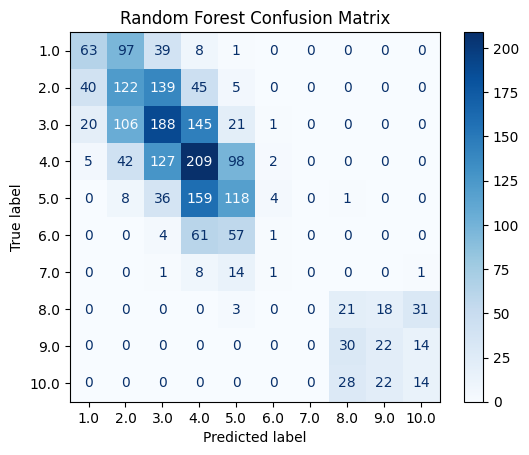

In [70]:
labels = sorted(yr_test.unique())

cm = confusion_matrix(
    yr_test,
    y_pred_rf,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

* The Random Forest classifier demonstrated superior predictive performance compared with the ordinal logistic regression model. It achieved an accuracy of 34.45%, correctly identifying the exact anxiety level in approximately 1 in every 3 observations.

* The model also obtained a weighted precision of 33.52%, weighted recall of 34.45%, and a weighted F1-score of 33.34%, indicating a more balanced classification performance across the anxiety levels.

* From an ordinal perspective, the Random Forest achieved a Mean Absolute Error (MAE) of 0.8523, meaning that predictions were, on average, less than one anxiety level away from the true value. Additionally, the model produced a Quadratic Weighted Cohen's Kappa (QWK) of 0.8456, indicating strong agreement between predicted and actual anxiety levels.

* Compared with the ordinal logistic regression model, the Random Forest achieved higher exact classification accuracy while simultaneously producing more accurate ordinal predictions.

## **Feature importance to see greatest determinants**

In [71]:
# numerical
importance = pd.DataFrame({
    "Feature": Xr_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                              Feature  Importance
7                 Stress Level (1-10)    0.114835
1                         Sleep Hours    0.090156
3            Caffeine Intake (mg/day)    0.088497
2        Physical Activity (hrs/week)    0.078015
8                    Heart Rate (bpm)    0.076245
0                                 Age    0.073611
4   Alcohol Consumption (drinks/week)    0.064821
9        Breathing Rate (breaths/min)    0.063654
15                Diet Quality (1-10)    0.055027
13       Therapy Sessions (per month)    0.053829
10               Sweating Level (1-5)    0.039863
12                         Medication    0.017796
14            Recent Major Life Event    0.017725
11                          Dizziness    0.017045
5                             Smoking    0.016984
17                       Gender_Other    0.015714
16                        Gender_Male    0.015565
6           Family History of Anxiety    0.012684
22              Occupation_Freelancer    0.008140


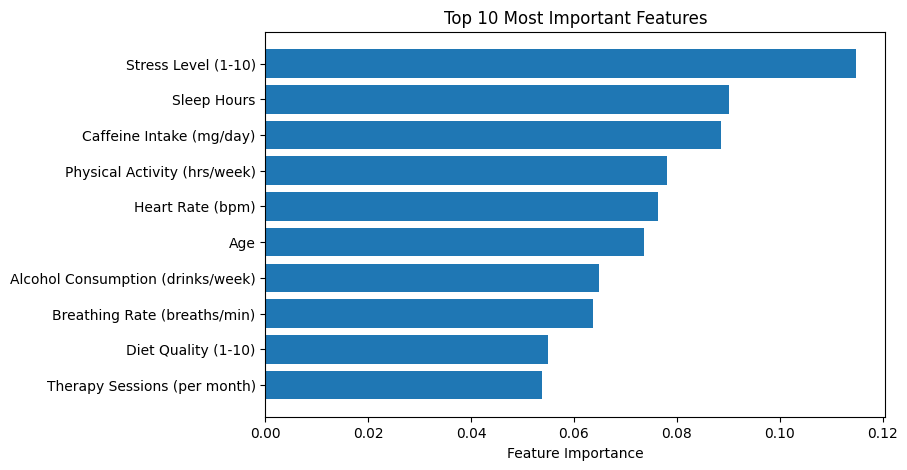

In [72]:
# visual
top = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.show()

* The Random Forest feature importance analysis identified Stress Level (Importance = 0.1148) as the strongest predictor of social anxiety, suggesting that perceived stress contributed the most to the model's predictions. This finding is consistent with existing psychological research, where elevated stress is closely associated with increased anxiety symptoms.
* Other highly influential variables included Sleep Hours (0.0902), Caffeine Intake (0.0885), Physical Activity (0.0780), Heart Rate (0.0762), and Age (0.0736). These results indicate that both lifestyle behaviors and physiological indicators play important roles in predicting anxiety severity.
* Lifestyle-related factors such as alcohol consumption, diet quality, and therapy sessions also demonstrated moderate importance, suggesting that multiple behavioral and health-related characteristics collectively contribute to anxiety prediction.
* In contrast, variables such as Smoking, Medication, Family History of Anxiety, Gender, and all Occupation categories exhibited relatively low feature importance values. While these factors may still contribute to prediction, their influence was considerably smaller compared with stress, sleep, physiological measures, and other lifestyle variables within this dataset.

## **Conclusion**

* Across all evaluation metrics, the Random Forest outperformed the ordinal logistic regression model.
* Accuracy, F1, Precision, and Recall were not the best metrics for evaluating both models, however both models observed high Mean Absolute Error (MAE) and Quadratic Weighted Cohen's Kappa (QWK), implying that while most predictions are not exactly the same with the actual, the predictions remain very very close to the true value.
* Both models experienced difficulty predicting the rarest anxiety categories, particularly Levels 6 and 7. This limitation is likely attributable to the class imbalance present in the dataset, where several higher anxiety levels were underrepresented.
* Feature importance analysis revealed that Stress Level was the strongest predictor of social anxiety, followed by Sleep Hours, Caffeine Intake, Physical Activity, Heart Rate, and Age. These findings suggest that behavioral, lifestyle, and physiological factors contribute more substantially to predicting anxiety severity than demographic variables such as gender or occupation.